# Cauer Ladder Circuit Modeling Example (로컬 가상환경 연동)

이 노트북은 구글 드라이브 동기화 부하가 없는 로컬 독립 가상환경(`~/.venv_acloss`)을 활용하여, `cauer_modeling.py` 모듈을 로드하고 **PMSM 헤어핀 권선(Hairpin Winding)의 AC 동손(AC Copper Loss)**을 분석하는 예제입니다.

## 0. 커널(Kernel) 설정 가이드
노트북을 실행하기 전에 우측 상단의 **Select Kernel** 버튼을 클릭하여 아래의 독립된 로컬 가상환경을 선택해 주세요.
* **가상환경 경로**: `~/.venv_acloss` (또는 `/Users/kdh2021-air/.venv_acloss/bin/python3`)
* 본 가상환경에는 계산에 필요한 `numpy`와 `matplotlib` 패키지가 이미 완벽하게 설치되어 있습니다.

## 1. 라이브러리 및 모듈 로드
현재 폴더에 있는 `cauer_modeling.py`를 가져오고, 필요한 라이브러리를 로드합니다.

In [7]:
# [1단계] Google Drive를 Colab 가상머신에 연결(마운트)합니다.
from google.colab import drive
drive.mount('/content/drive')

# [2단계] cauer_modeling.py가 위치한 구글 드라이브 내 'ACloss' 폴더 경로를 파이썬 검색 경로에 추가합니다.
import os
import sys

# 구글 드라이브 동기화 상태에 따라 'My Drive' 또는 'MyDrive'로 지정됩니다.
colab_path = '/content/drive/MyDrive/ACloss'
if not os.path.exists(colab_path):
    colab_path = '/content/drive/My Drive/ACloss'

# 작업 공간을 해당 폴더로 이동하고, 파이썬 모듈 검색 경로(sys.path)에 추가합니다.
if os.path.exists(colab_path):
    os.chdir(colab_path)
    if colab_path not in sys.path:
        sys.path.append(colab_path)
    print(f"작업 디렉토리 변경 성공: {colab_path}")
else:
    print("경로를 찾을 수 없습니다. 구글 드라이브 내 ACloss 폴더 명칭을 확인해 주세요.")

# [3단계] 이제 로컬 모듈처럼 바로 import 하시면 됩니다.
import cauer_modeling


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
작업 디렉토리 변경 성공: /content/drive/MyDrive/ACloss


In [8]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# 현재 작업 디렉토리 경로 추가 (cauer_modeling.py 로드용)
module_path = os.path.abspath('')
if module_path not in sys.path:
    sys.path.append(module_path)

import cauer_modeling
print("모듈 로드 완료!")

모듈 로드 완료!


## 2. 물리적 파라미터 정의 및 Cauer 회로 파라미터 계산

모터의 물리적 치수와 권선 조건(예: 8극 48슬롯 헤어핀 와인딩 모터)을 입력하여 Cauer 회로의 각 단(Stage)별 등가 저항 $R$ 및 인덕턴스 $L$ 값을 계산합니다.
* 팁: `cauer_modeling.py`의 $L_{core}$ 스케일링 오류(나눗셈 $\rightarrow$ 곱셈)가 이미 수정되어 정상 범위로 계산됩니다.

In [9]:
# 모터 기하학적 치수 및 재질 조건 정의
D_COND = 0.002      # 2 mm (도체의 높이/두께)
W_SLOT = 0.006      # 6 mm (슬롯 폭)
SIGMA = 5.8e7       # 20°C 기준 구리 전도도 [S/m]
L_CORE = 0.15       # 150 mm (철심 적층 길이)
TURNS = 6           # 슬롯당 턴 수 (헤어핀 개수)
STAGES = 5          # Cauer 회로 단수 (정밀도 결정을 위한 파라미터)

# Cauer 회로 파라미터 계산
params = cauer_modeling.calculate_cauer_parameters(
    d_cond=D_COND,
    w_slot=W_SLOT,
    sigma=SIGMA,
    l_core=L_CORE,
    num_turns=TURNS,
    num_stages=STAGES
)

print("==========================================================")
print(" Cauer 회로 파라미터 계산 결과 (물리 오류 수정 반영)")
print("==========================================================")
print(f"총 상당 DC 저항 (슬롯 근사): {params['R_dc_total']:.6f} Ohm")
print(f"단일 턴(Turn)당 DC 저항: {params['R_dc_per_turn']:.6f} Ohm")
print("\n도체(Turn)당 계산된 Cauer 회로 파라미터 (단별 값):")
for idx in range(STAGES):
    print(f"  [Stage {idx+1}]")
    print(f"    - AC 저항 (R_{idx+1}): {params['Cauer_R_stages'][idx]:.6f} Ohm")
    print(f"    - 와전류 인덕턴스 (L_{idx+1}): {params['Cauer_L_stages'][idx]*1e6:.4f} uH")
print("==========================================================")

 Cauer 회로 파라미터 계산 결과 (물리 오류 수정 반영)
총 상당 DC 저항 (슬롯 근사): 0.001293 Ohm
단일 턴(Turn)당 DC 저항: 0.000216 Ohm

도체(Turn)당 계산된 Cauer 회로 파라미터 (단별 값):
  [Stage 1]
    - AC 저항 (R_1): 0.005172 Ohm
    - 와전류 인덕턴스 (L_1): 0.0628 uH
  [Stage 2]
    - AC 저항 (R_2): 0.012069 Ohm
    - 와전류 인덕턴스 (L_2): 0.0126 uH
  [Stage 3]
    - AC 저항 (R_3): 0.018966 Ohm
    - 와전류 인덕턴스 (L_3): 0.0070 uH
  [Stage 4]
    - AC 저항 (R_4): 0.025862 Ohm
    - 와전류 인덕턴스 (L_4): 0.0048 uH
  [Stage 5]
    - AC 저항 (R_5): 0.032759 Ohm
    - 와전류 인덕턴스 (L_5): 0.0037 uH


## 3. 주파수별 AC 저항 증가 계수 및 등가 인덕턴스 계산

주파수 대역($0 \sim 5000\text{ Hz}$)을 설정하고 Cauer 회로의 입력 임피던스를 분석하여 AC 저항 증가 비율($Fr = R_{ac}/R_{dc}$)과 주파수별 AC 등가 인덕턴스($L_{ac}$)를 구합니다.

In [10]:
# 주파수 범위 설정 (0 Hz ~ 5 kHz)
freqs = np.linspace(0, 5000, 500)
fr_factors, lac_values = cauer_modeling.analyze_frequency_response(params, freqs)

print("주요 주파수 대역별 분석 요약:")
for f_target in [100, 500, 1000, 2000, 5000]:
    idx = np.abs(freqs - f_target).argmin()
    print(f"  At {f_target:4d} Hz  ->  Fr (Rac/Rdc): {fr_factors[idx]:.4f}  |  AC 인덕턴스 (Lac): {lac_values[idx]*1e6:.4f} uH")

주요 주파수 대역별 분석 요약:
  At  100 Hz  ->  Fr (Rac/Rdc): 24.0006  |  AC 인덕턴스 (Lac): 0.0628 uH
  At  500 Hz  ->  Fr (Rac/Rdc): 24.0150  |  AC 인덕턴스 (Lac): 0.0628 uH
  At 1000 Hz  ->  Fr (Rac/Rdc): 24.0601  |  AC 인덕턴스 (Lac): 0.0628 uH
  At 2000 Hz  ->  Fr (Rac/Rdc): 24.2391  |  AC 인덕턴스 (Lac): 0.0625 uH
  At 5000 Hz  ->  Fr (Rac/Rdc): 25.4415  |  AC 인덕턴스 (Lac): 0.0609 uH


## 4. 주파수 응답 결과 시각화

주파수 변화에 따른 AC 저항 계수(붉은 실선)와 등가 인덕턴스(푸른 점선)를 하나의 그래프에 듀얼 Y축으로 플로팅합니다.

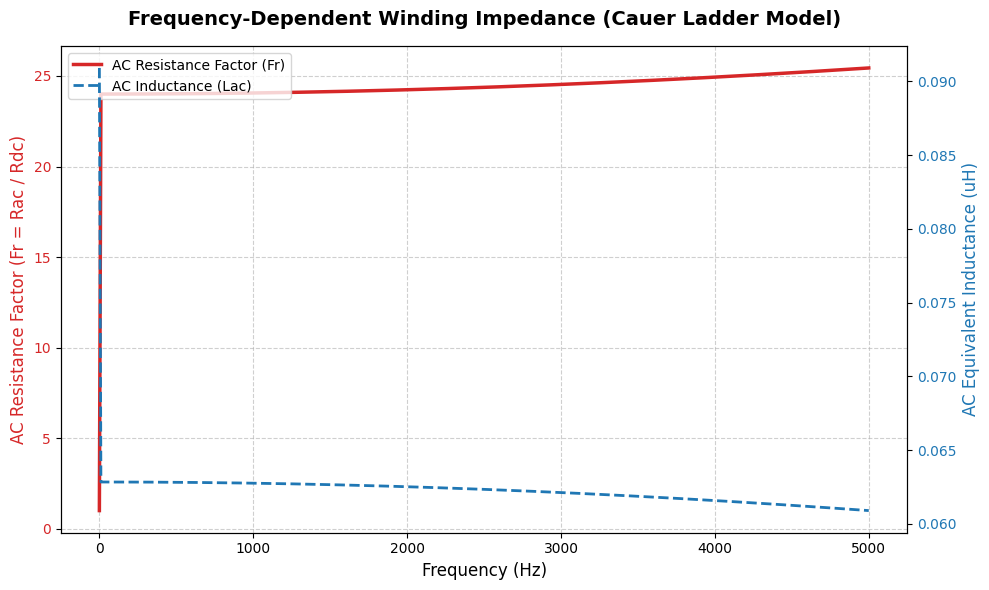

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# AC 저항 계수 플로팅 (좌측 Y축)
color = 'tab:red'
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('AC Resistance Factor (Fr = Rac / Rdc)', color=color, fontsize=12)
line1 = ax1.plot(freqs, fr_factors, color=color, linewidth=2.5, label='AC Resistance Factor (Fr)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# AC 등가 인덕턴스 플로팅 (우측 Y축)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('AC Equivalent Inductance (uH)', color=color, fontsize=12)
line2 = ax2.plot(freqs, lac_values * 1e6, color=color, linestyle='--', linewidth=2, label='AC Inductance (Lac)')
ax2.tick_params(axis='y', labelcolor=color)

# 범례 병합 표시
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Frequency-Dependent Winding Impedance (Cauer Ladder Model)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 5. Cauer 회로 모델 시각화 (신규 추가)

새로 작성한 `cauer_visualization.py` 모듈을 이용하여 Cauer 래더 회로의 연결 상태와 각 단(Stage)별 계산된 R, L 값을 회로도 형식으로 시각화합니다.

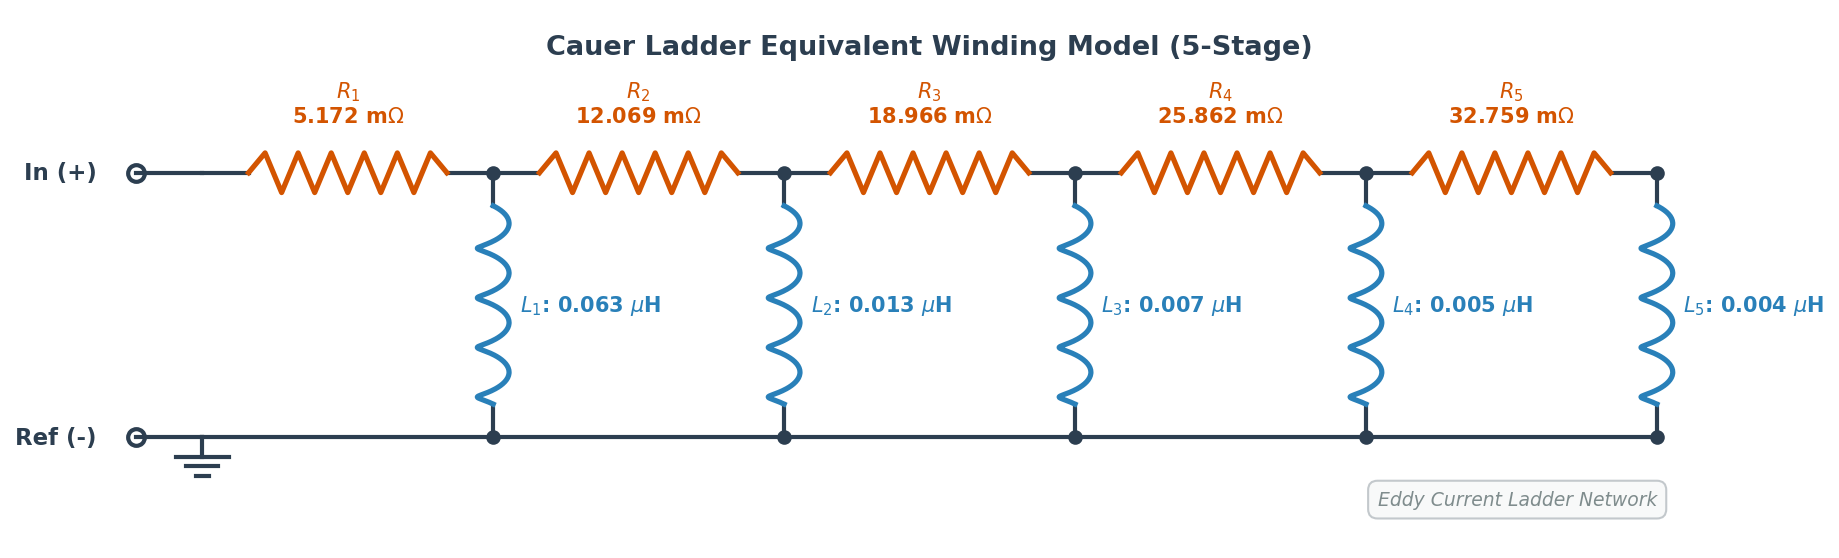

In [12]:
# 시각화 모듈 로드 및 회로도 생성
import cauer_visualization

# 회로도 그리기 및 저장
fig, ax = cauer_visualization.draw_cauer_schematic(
    params,
    save_path='cauer_circuit_schematic.png'
)
plt.show()
